# IODA Format and IODA converters

## Introduction

The IODA (Interface for Observation Data Access) format is a standardized data format used within the JEDI framework to store, access, and manipulate observational data. In the IODA format, observations are organized into groups that separate measured values, errors, metadata, and quality control information. IODA uses NetCDF as the underlying storage format and you can view or manupulate the IODA files using the commands you usually use for any NetCDF file, with some minor updates to handle "Groups" within the NetCDF file.

In order to prepare observations to be used in JEDI we run [IODA-converters](https://github.com/jcsda-internal/ioda-converters) to convert the observation files from their raw format into the IODA format. IODA-converters are written in Python and are typically structured to:

1. Read raw observation data.
2. Exctract variables and metadata needed by the observation operator or filters.
3. Apply necessary transformations or unit conversions.
4. Organize the data into IODA groups.
5. Write out IODA file using `pyioda` (Python bindings to the underlying IODA C++ libraries). 


You can use an [existing converter](https://github.com/jcsda-internal/ioda-converters) or write a new one to convert your raw observations into the IODA format. Outputs from JEDI that are in observation space, such as feedback files, are also written in IODA format.

## Example of a IODA file and the IODA format

IODA files are nested NetCDF files that are organized into Groups such as `ObsValue`, `ObsError`, `MetaData`, `PreQC`, etc. Let's review an example of a TEMPO observation file that is in the IODA format. 

**Note:** Users are not expected to run the Python code shown in this training. The outputs are provided directly below each code block. If you would like to run the code yourself, you will need a newer version of Xarray (2024.10.0 or later) that supports `xr.open_datatree` and DataTree.

In [1]:
import xarray as xr
obs_file = xr.open_datatree('./inputs/tempo_no2_tropo_20230805T150000Z.nc')

# Loop through each group in the file
for group_name in obs_file.groups:
    print(f"\n=== Group: {group_name} ===")

    group = obs_file[group_name]

    # List data variables
    if group.data_vars:
        print("  Data variables:")
        for var in group.data_vars:
            print(f"    - {var}")
    else:
        print("  Data variables: None")



=== Group: / ===
  Data variables: None

=== Group: /MetaData ===
  Data variables:
    - albedo
    - cloud_fraction
    - dateTime
    - latitude
    - longitude
    - quality_assurance_value
    - solar_zenith_angle
    - viewing_zenith_angle

=== Group: /ObsError ===
  Data variables:
    - nitrogendioxideColumn

=== Group: /ObsValue ===
  Data variables:
    - nitrogendioxideColumn

=== Group: /PreQC ===
  Data variables:
    - nitrogendioxideColumn

=== Group: /RetrievalAncillaryData ===
  Data variables:
    - averagingKernel
    - pressureVertice


Note what's stored under `ObsValue` Group. The observation name is set to `nitrogendioxideColumn` in this file. IODA format follows the JEDI naming conventions for naming the variables. You can see the full list [here](https://github.com/JCSDA/ioda/blob/develop/share/ioda/yaml/validation/ObsSpace.yaml). 

Also, note what's stored under the `MetaData` Group. Under `MetaData` variables such as `albedo`, `cloud_fraction`, `solar_zenith_angle`, etc. are stored. Later in [another practical example](https://mer-a-o.github.io/howtojedi/run-hofx3d-with-filters/) you will learn how to use these variables to filter observation points based on `cloud_fraction` and `solar_zenith_angle`. This IODA observation file is generated by running the [TEMPO IODA converter](https://github.com/JCSDA-internal/ioda-converters/blob/develop/src/compo/tempo_nc2ioda.py). You can review this converter to see how each variable is mapped from the raw file to the IODA file. 

IODA files that are generated as the JEDI application output, feedback files, may have additional Groups such as `hofx` or `EffectiveQC` but the structure remains similar. You can find more information in the [HofX tutorial](https://mer-a-o.github.io/howtojedi/run-hofx3d/#hofx3d).

## Running IODA-Converters

A copy of the tropomi ioda-convert and an example input file is available under `jedi_obs` directory of this repository. `cd` into this directory before running the converter.

Follow the instruction [here](https://mer-a-o.github.io/howtojedi/discover/#using-pre-built-jedi) load the JEDI modules and setup your work environment. You can typically run the IODA converters on the login nodes. 

```bash
source /discover/nobackup/projects/gmao/advda/swell/jedi_modules/spackstack_1.9_intel
export JEDI_BUILD=/discover/nobackup/projects/jcsda/s2127/maryamao/geos-esm/jedi-work/build-intel-release/bin
```

Add ioda python bindings to `PYTHONPATH` by running:

```bash
PYTHON_VERSION=`python3 -c 'import sys; version=sys.version_info[:2]; print("{0}.{1}".format(*version))'`
export PYTHONPATH=${JEDI_BUILD}/../lib/python${PYTHON_VERSION}:${PYTHONPATH}
```

Finally run the convert using:

```bash
python3 $JEDI_BUILD/tropomi_no2_co_nc2ioda.py \
  -i inputs/obs.tropomi_co_raw.nc \
  -o obs.tropomi_co_ioda.nc \
  -v co \
  -c total \
  -q 0.5
  ```

For this converter `-i` is the input observation file, `-o` is the output observation file in IODA format, `-v` is the variable which can be either `no2` or `co`, `-c` is the column which can be `total` or `tropospheric` (for NO2), and `-q` is the `qa_value` which can be used as a preprocessing step to remove observations with unacceptable quality value. 

Review the output in IODA format (`obs.tropomi_co_ioda.nc`) and compare it with the TEMPO in IODA format (`inputs/tempo_no2_tropo_20230805T150000Z.nc`). Note that the structure of the files is similar, but the variable name (among other things) is different.

## Simple plotting of observation file
There are many ways one can plot a IODA observation file. Here we provide an example of plotting maps of `ObsValue/nitrogendioxideColumn` for the TEMPO tropospheric column observations.

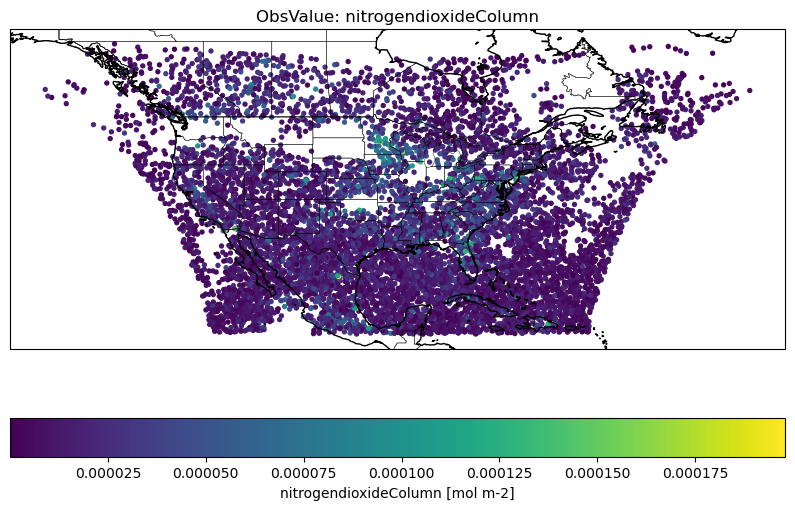

In [32]:
# Plotting TEMPO observation

import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

obs_file = xr.open_datatree('./inputs/tempo_no2_tropo_20230805T150000Z.nc')
var_name = 'nitrogendioxideColumn'
obs = obs_file['ObsValue'][var_name]
lat = obs_file['MetaData']['latitude']
lon = obs_file['MetaData']['longitude']

# Create map
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.3)

# Plot observations
sc = ax.scatter(
    lon,
    lat,
    c=obs,
    s=8,
    transform=ccrs.PlateCarree()
)

# Colorbar
plt.colorbar(sc, ax=ax, label=f'{var_name} [{obs.units}]', orientation='horizontal')

plt.title(f'ObsValue: {var_name}')
plt.show()


## Ctest in IODA-converters

Each converter in the IODA-converters repository has a dedidacted unit test that is there to ensure the converter is working properly. The ctests can also be used as a references to learn how the converters run, what are the requred inputs, and what the outputs look like. Let's take a look at the TROPOMI CO ioda converter. 

In [ioda-converters/test/CMakeLists.txt](https://github.com/JCSDA-internal/ioda-converters/blob/develop/test/CMakeLists.txt) find where TROPOMI CO test is added:


```C++
ecbuild_add_test( TARGET  test_${PROJECT_NAME}_tropomi_co_total
                  TYPE    SCRIPT
                  ENVIRONMENT "PYTHONPATH=${IODACONV_PYTHONPATH}"
                  COMMAND bash
                  ARGS    ${CMAKE_BINARY_DIR}/bin/iodaconv_comp.sh
                          netcdf
                          "${Python3_EXECUTABLE} ${CMAKE_BINARY_DIR}/bin/tropomi_no2_co_nc2ioda.py
                          -i testinput/tropomi_co.nc
                          -o testrun/tropomi_co_total.nc
                          -v co
                          -q 0.5
                          -c total"
                          tropomi_co_total.nc ${IODA_CONV_COMP_TOL})
```

Here you can see the convert's name `tropomi_no2_co_nc2ioda.py` and the inputs used when running this converter. There are additional arguments that are used by the unit test (such as `iodaconv_comp.sh` and `${IODA_CONV_COMP_TOL}` that can be ignored for this discussion.



## Homework

In `jedi_obs/inputs` directory you can see a raw TROPOMI NO2 observation file. Run `tropomi_no2_co_nc2ioda.py` converter again but this time for NO2 "total" and NO2 "tropospheric" observation using the raw TROPOMI NO2 observation file as an input. You find use the tropomi ctest [ioda-converters/test/CMakeLists.txt](https://github.com/JCSDA-internal/ioda-converters/blob/develop/test/CMakeLists.txt) a reference. 

How does the variable name under `ObsValue` group changes for `total` vs `tropospheric` column?

# Next step

Now that you are familiar with the IODA format and observations files you can run a simple `HofX3D` experiment follow this [practical example](https://mer-a-o.github.io/howtojedi/run-hofx3d/).